# 4: Linear Regression From Scratch

In [77]:
# Library Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Boston Housing Dataset - Taken from [Housing Price demo](https://colab.research.google.com/drive/1myH2V4xbKXZzdF-49ma_vWHLfArTyO2W?usp=sharing)

In [78]:
class BostonHousingDataset:
    def __init__(self):
        self.url = "http://lib.stat.cmu.edu/datasets/boston"
        self.feature_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

    def load_dataset(self):
        # Fetch data from URL
        raw_df = pd.read_csv(self.url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

        # Create the dictionary in sklearn format
        dataset = {
            'data': [],
            'target': [],
            'feature_names': self.feature_names,
            'DESCR': 'Boston House Prices dataset'
        }

        dataset['data'] = data
        dataset['target'] = target

        return dataset

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3067/2325054334.py:8: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(self.url, sep="\s+", skiprows=22, header=None)


In [79]:
# Load the Boston Housing Dataset from sklearn
boston_housing = BostonHousingDataset()
boston_dataset = boston_housing.load_dataset()
boston_dataset.keys(), boston_dataset['DESCR']

(dict_keys(['data', 'target', 'feature_names', 'DESCR']),
 'Boston House Prices dataset')

In [80]:
# Create the dataset
boston = pd.DataFrame(boston_dataset['data'], columns=boston_dataset['feature_names'])
boston['MEDV'] = boston_dataset['target']
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Data Exploration - Taken from [Housing Price demo](https://colab.research.google.com/drive/1myH2V4xbKXZzdF-49ma_vWHLfArTyO2W?usp=sharing)

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


/tmp/ipykernel_3067/801501802.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(boston['MEDV'], bins=30)


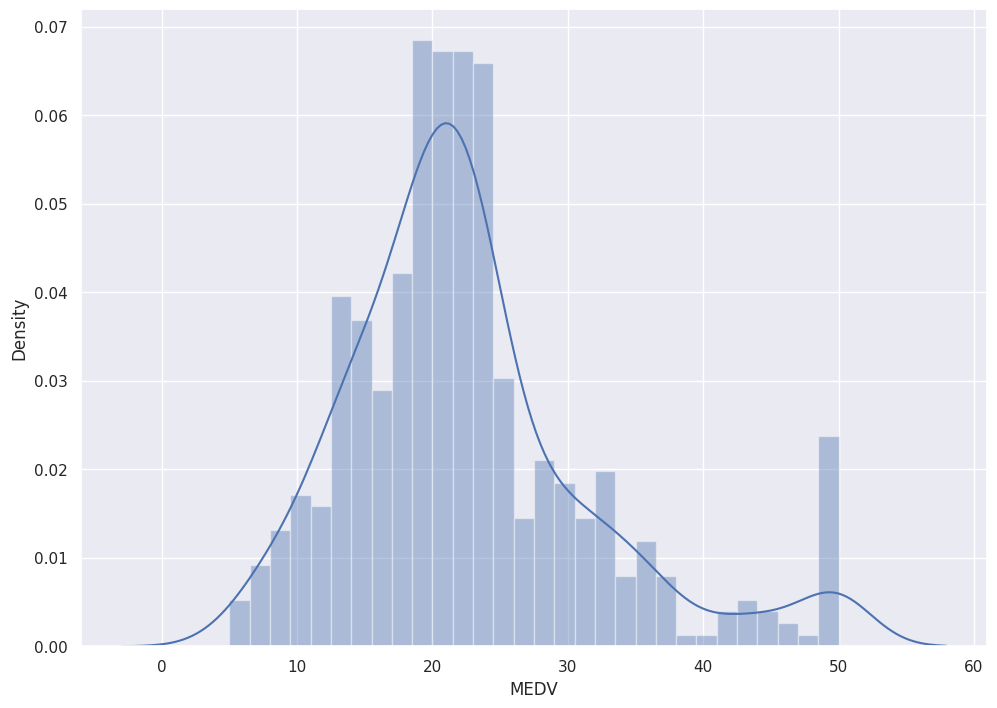

<Axes: >

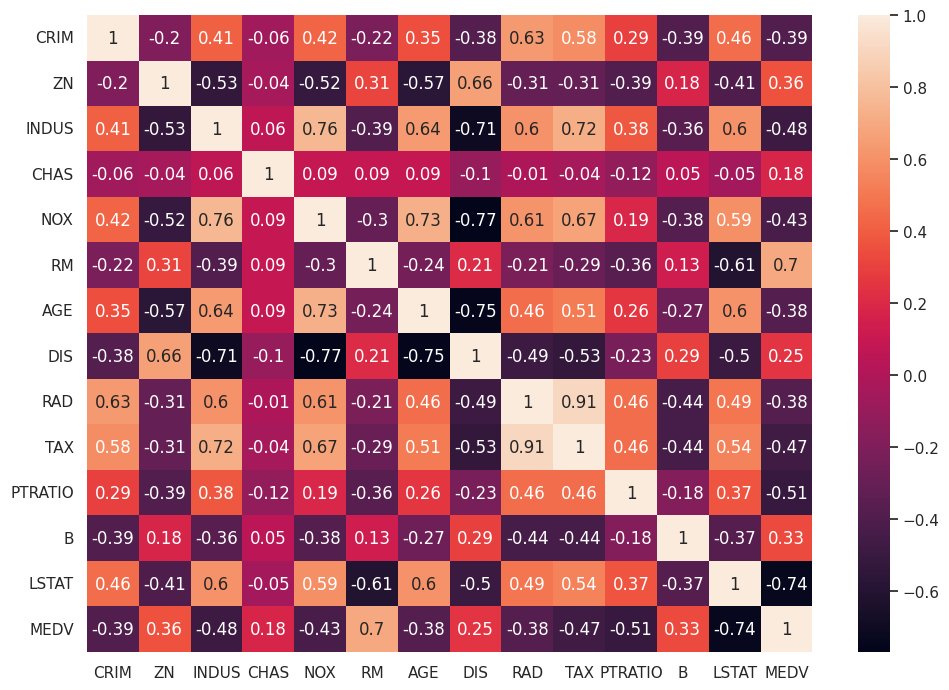

In [81]:
# Ensure no NAN values
print(boston.isnull().sum())

# Plotting MEDV distribution
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.distplot(boston['MEDV'], bins=30)
plt.show()

# Correlation matrix
correlation_matrix = boston.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True)

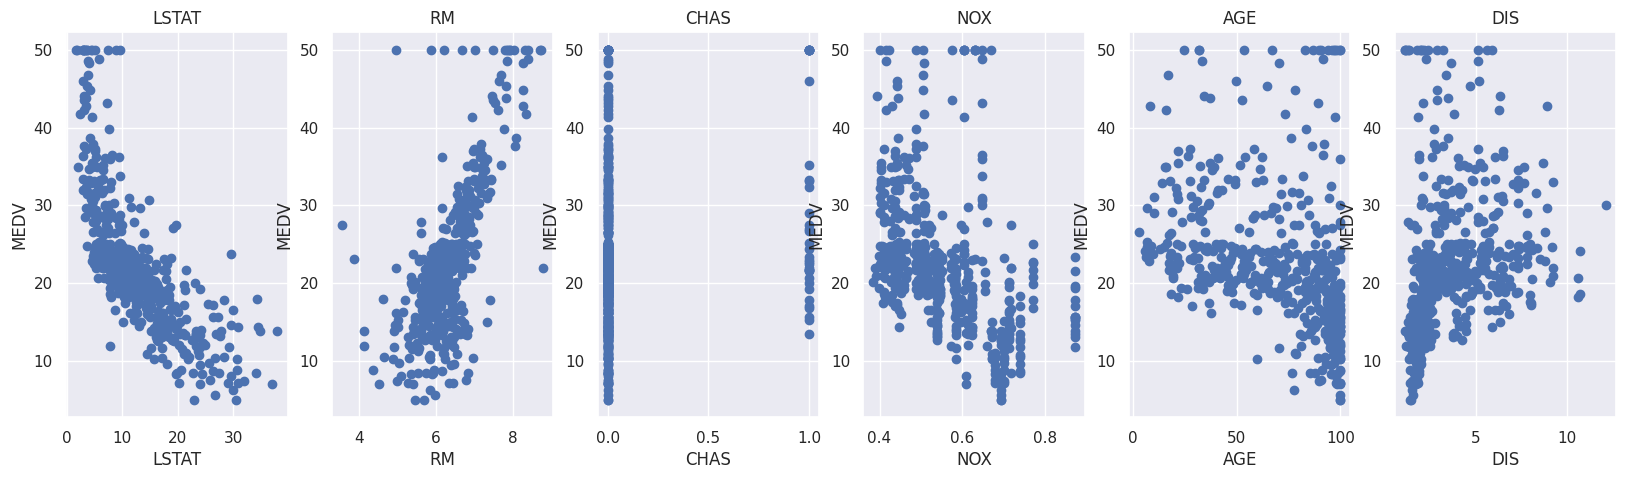

In [82]:
# How do the features relate to the target variable? (MEDV)

plt.figure(figsize=(20, 5))

features = ['LSTAT', 'RM','CHAS','NOX','AGE','DIS']
target = boston['MEDV']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = boston[col]
    y = target
    plt.scatter(x, y, marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('MEDV')

## Train/Test Split

In [83]:
from sklearn.model_selection import train_test_split

X = boston.to_numpy()

X = np.delete(X, 13, 1)

y = boston['MEDV'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)

## Linear Regression from Scratch

In [84]:
# Initialize parameters to 0

w = np.zeros(X_train.shape[1])
b = 0.0

print("w shape:", w.shape)
print("b:", b)

def predict(X, w, b):
    return X @ w + b

y_pred = predict(X_train, w, b)
print("y_pred shape:", y_pred.shape)
print(y_pred[:5])

w shape: (13,)
b: 0.0
y_pred shape: (404,)
[0. 0. 0. 0. 0.]


### Implement MSE

In [85]:
def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

# Test the MSE loss function

loss = mse_loss(y_train, y_pred)

print("MSE:", loss)


MSE: 598.7784405940595


#### Implement Gradient Descent for MSE

In [86]:
# Calculates the gradient of the mean squared error loss with respect to the weights and bias

def mse_gradient(X, y_true, y_pred):
    n = len(y_true)
    
    error = y_pred - y_true
    
    grad_w = (2 / n) * (X.T @ error)
    grad_b = (2 / n) * np.sum(error)
    
    return grad_w, grad_b

grad_w, grad_b = mse_gradient(X_train, y_train, y_pred)

print("Gradient w shape:", grad_w.shape)
print("Gradient b:", grad_b)

Gradient w shape: (13,)
Gradient b: -45.29356435643564


In [87]:
# Create training loop

def train_mse(X, y, learning_rate=0.001, n_iters=1000):
    # Initialize parameters
    w = np.zeros(X.shape[1])
    b = 0.0
    
    # Keep track of loss
    loss_history = []
    
    # Gradient descent: make preds --> calc loss --> calc gradients --> update params
    for i in range(n_iters):
        
        y_pred = predict(X, w, b)
        
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)
        
        grad_w, grad_b = mse_gradient(X, y, y_pred)
        
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
    
    return w, b, loss_history

In [88]:
# Standardize Features (Avoids blowing up the gradients)

X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Training means:", np.mean(X_train_scaled, axis=0))
print("Training stds:", np.std(X_train_scaled, axis=0))

Training means: [ 1.81785280e-16 -1.47296916e-16  2.35455220e-15 -2.28365182e-16
 -2.17922490e-15 -7.21919774e-16  9.15659188e-16  4.28699980e-16
  7.47476888e-17  4.96027861e-17  2.06567436e-14  5.52892440e-15
 -7.07629774e-16]
Training stds: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Weights: [-1.08254633  1.04673926 -0.26665804  0.72759178 -1.71875758  2.42386964
 -0.01320671 -3.02394011  2.40581927 -1.37953677 -2.04661198  1.04032867
 -4.14793212]
Bias: 22.646782132464892
Final MSE: 22.559970143210865


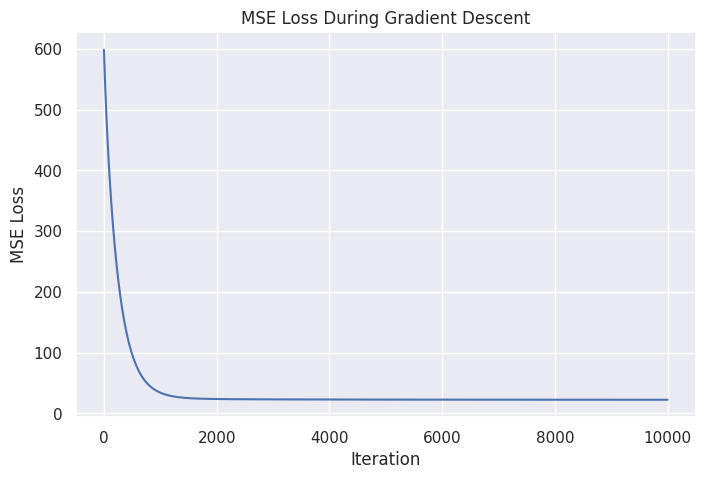

In [100]:
# Run training loop for MSE loss

w_mse, b_mse, mse_history = train_mse(
    X_train_scaled,
    y_train,
    learning_rate=0.001,
    n_iters=10000
)

print("Weights:", w_mse)
print("Bias:", b_mse)
print("Final MSE:", mse_history[-1])

plt.figure(figsize=(8, 5))
plt.plot(mse_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("MSE Loss During Gradient Descent")
plt.show()

#### Evaluate Model

In [101]:
# Evaluate MSE-trained model
mse_y_pred_train = predict(X_train_scaled, w_mse, b_mse)
mse_y_pred_test = predict(X_test_scaled, w_mse, b_mse)

mse_train_mse = mse_loss(y_train, mse_y_pred_train)
mse_test_mse = mse_loss(y_test, mse_y_pred_test)

print("MSE Model")
print("Training MSE:", mse_train_mse)
print("Test MSE:", mse_test_mse)

# Save model results for later comparison
mse_model_results = {
    "weights": w_mse,
    "bias": b_mse,
    "loss_history": mse_history,
    "train_mse": mse_train_mse,
    "test_mse": mse_test_mse
}

MSE Model
Training MSE: 22.559949815416903
Test MSE: 20.660912983705906


### Implement MAE

In [91]:
def mae_loss(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))

#### Implement Gradient Descent for MAE

In [92]:
def mae_gradient(X, y_true, y_pred):
    n = len(y_true)
    
    error = y_pred - y_true
    sign_error = np.sign(error)
    
    grad_w = (1 / n) * (X.T @ sign_error)
    grad_b = (1 / n) * np.sum(sign_error)
    
    return grad_w, grad_b

In [93]:
# Training function for MAE

def train_mae(X, y, learning_rate=0.01, n_iters=1000):
    w = np.zeros(X.shape[1])
    b = 0.0
    
    loss_history = []
    
    for i in range(n_iters):
        # Make predictions
        y_pred = predict(X, w, b)
        
        # Calculate MAE
        loss = mae_loss(y, y_pred)
        loss_history.append(loss)
        
        # Calculate subgradients
        grad_w, grad_b = mae_gradient(X, y, y_pred)
        
        # Update parameters
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
    
    return w, b, loss_history

Initial MAE: 22.64678217821782
Final MAE: 12.800684381230273


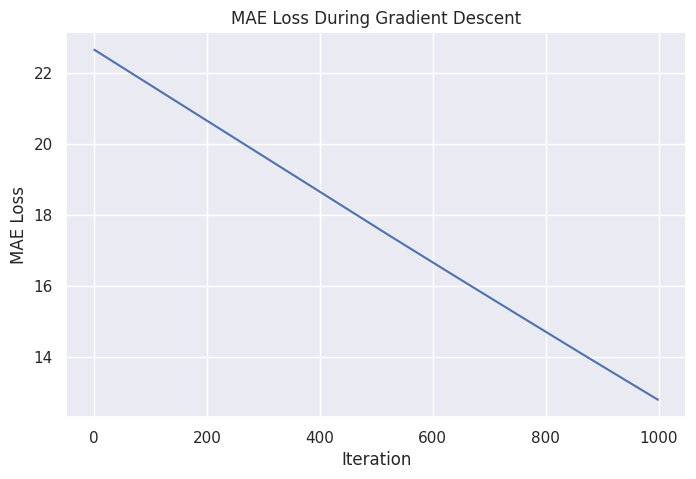

In [94]:
# Training loop for MAE

w_mae, b_mae, mae_history = train_mae(
    X_train_scaled,
    y_train,
    learning_rate=0.01,
    n_iters=1000
)

print("Initial MAE:", mae_history[0])
print("Final MAE:", mae_history[-1])

plt.figure(figsize=(8, 5))
plt.plot(mae_history)
plt.xlabel("Iteration")
plt.ylabel("MAE Loss")
plt.title("MAE Loss During Gradient Descent")
plt.show()

#### Evaluate Model

In [95]:
# Evaluate MAE-trained model
mae_y_pred_train = predict(X_train_scaled, w_mae, b_mae)
mae_y_pred_test = predict(X_test_scaled, w_mae, b_mae)

mae_train_mae = mae_loss(y_train, mae_y_pred_train)
mae_test_mae = mae_loss(y_test, mae_y_pred_test)

print("MAE Model")
print("Training MAE:", mae_train_mae)
print("Test MAE:", mae_test_mae)

# Save model results for later comparison
mae_model_results = {
    "weights": w_mae,
    "bias": b_mae,
    "loss_history": mae_history,
    "train_mae": mae_train_mae,
    "test_mae": mae_test_mae
}

MAE Model
Training MAE: 12.791112715820239
Test MAE: 12.38585987647434


## Compare to sklearn Linear Regression

In [96]:
# Run sklearn Linear Regression model and save results

from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)
sklearn_y_pred_train = sklearn_model.predict(X_train_scaled)
sklearn_y_pred_test = sklearn_model.predict(X_test_scaled)

sklearn_train_mse = mse_loss(y_train, sklearn_y_pred_train)
sklearn_test_mse = mse_loss(y_test, sklearn_y_pred_test)

sklearn_train_mae = mae_loss(y_train, sklearn_y_pred_train)
sklearn_test_mae = mae_loss(y_test, sklearn_y_pred_test)

print("Sklearn Linear Regression Model")
print("Training MSE:", sklearn_train_mse)
print("Test MSE:", sklearn_test_mse)
print("Training MAE:", sklearn_train_mae)
print("Test MAE:", sklearn_test_mae)

sklearn_model_results = {
    "weights": sklearn_model.coef_,
    "bias": sklearn_model.intercept_,
    "train_mse": sklearn_train_mse,
    "test_mse": sklearn_test_mse
}

Sklearn Linear Regression Model
Training MSE: 22.477090408387628
Test MSE: 20.869292183770813
Training MAE: 3.350009519648453
Test MAE: 3.2132704958423823


In [102]:
# Create a table to compare all results
mse_results = pd.DataFrame({
    "Model": [
        "MSE Gradient Descent",
        "sklearn Linear Regression"
    ],
    "Training MSE": [
        mse_train_mse,
        sklearn_train_mse
    ],
    "Test MSE": [
        mse_test_mse,
        sklearn_test_mse
    ]
})



mae_results = pd.DataFrame({
    "Model": ["MAE Gradient Descent"],
    "Training MAE": [mae_train_mae],
    "Test MAE": [mae_test_mae]
})

print(mse_results)
print()
print(mae_results)


                       Model  Training MSE   Test MSE
0       MSE Gradient Descent      22.55995  20.660913
1  sklearn Linear Regression      22.47709  20.869292

                  Model  Training MAE  Test MAE
0  MAE Gradient Descent     12.791113  12.38586


### Comments on Manual MSE vs sklearn

Both the manual MSE model and sklearn model had higher training losses than test losses (manual MSE training loss was 22.56 and test loss was 20.66 while sklearn's training loss was 22.48 and test loss was 20.87), but we see that the values themselves are quite similar. The similarity in scores between models means that the manual MSE was implemented correctly and adjusts the weight and bias such that loss is minimized. One observation I had with the manual MSE model is that it required more iterations in order to properly converge. Earlier, I had tried it with 1000 iterations at a .01 learning rate, and the training loss was 34.2 while the test loss was 31.03. This was significantly higher than the loss posed by the sklearn model, prompting me to try runinng the manual model again but with more iterations (a higher learning rate could also have helped bring the loss down, but could also lead to divergence on later iterations).


### Comments on Manual MAE

The manual implementation of MAE cannot be compared to sklearn's model because sklearn is minimizing MSE. Optimizing MAE is different from optimizing MSE in that MAE more linearly penalizes errors as it uses the absolute value. On the other hand, MSE more heavily penalizes errors (especially errors with a big difference from the true value) because of the squared portion.